# WISDM Dataset 기반 RNN 분류

### 결과 분석

Test accuracy:71.38%

WISDM 데이터셋을 SimpleRNN 기반 모델로 학습한 결과 정확도는 71.38%로 낮게 나타났다.

실험 결과 walking, sitting, standing과 같이 패턴이 비교적 뚜렷한 클래스는 잘 분류되었지만 Upstairs와 Downstairs는 낮은 recall을 보였다.

WISDM 데이터의 핵심 난제가 단순한 클래스 불균형이 아니라 가속도 센서만으로 Walking, Upstairs, Downstairs처럼 유사한 주기적 움직임을 가지는 동적 활동 간의 미세한 차이를 구분하는 데 있음을 보여준다.

시점을 순차적으로 처리하며 시간 흐름을 학습하는 SimpleRNN은 HAR 데이터에서  local temporal pattern을 강하게 추출하는 데 한계가 있다.

따라서 WISDM 데이터셋에서는 SimpleRNN 단독 구조만으로는 한계가 있다고 판단된다.



In [ ]:
# 라이브러리 import
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, SimpleRNN, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [ ]:
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [ ]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [ ]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")


Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [ ]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])

In [ ]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [ ]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## Model 1
- RNN 3 (SimpleRNN 3개)

In [ ]:
# RNN은 (timesteps, features) 입력 구조
input_shape = (x_train.shape[1], x_train.shape[2])
# 분류할 동작 개수
num_classes = len(label_encoder.classes_)

# 모델 정의 (Sequential: 층을 순서대로 쌓는 구조)
model1 = Sequential([
    Input(shape=input_shape),

    # 첫 번째 RNN 레이어
    SimpleRNN(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
    # 두 번째 RNN 레이어
    SimpleRNN(64, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
    # 세 번째 RNN 레이어
    SimpleRNN(32, dropout=0.1, recurrent_dropout=0.1),

    # RNN이 뽑은 특징을 기반으로 비선형 변환
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model1.compile(
    optimizer=Adam(learning_rate=0.0005),
    # 정답이 정수 라벨 (0~5)일 때 사용하는 다중 분류용 손실 함수
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,350 (145.90 KB)

 Trainable params: 37,350 (145.90 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
callbacks1 = [
    ModelCheckpoint(
        "WISDM_HAR_RNN3_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=25,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.5905 - sparse_categorical_accuracy: 0.2578
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.44244, saving model to WISDM_HAR_RNN3_best.h5



Epoch 1: finished saving model to WISDM_HAR_RNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - loss: 1.4599 - sparse_categorical_accuracy: 0.3178 - val_loss: 1.4404 - val_sparse_categorical_accuracy: 0.4424 - learning_rate: 5.0000e-04
Epoch 2/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.2670 - sparse_categorical_accuracy: 0.4392
Epoch 2: val_sparse_categorical_accuracy improved from 0.44244 to 0.54707, saving model to WISDM_HAR_RNN3_best.h5



Epoch 2: finished saving model to WISDM_HAR_RNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - loss: 1.2412 - sparse_categorical_accuracy: 0.4644 - val_loss: 1.2850 - val_sparse_categorical_accuracy: 0.5471 - learning_rate: 5.0000e-04
Epoch 3/200
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1999 - sparse_categorical_accuracy: 0.4969
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.54707
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 1.1950 - sparse_categorical_accuracy: 0.4887 - val_loss: 1.2612 - val_sparse_categorical_accuracy: 0.5239 - learning_rate: 5.0000e-04
Epoch 4/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.0992 - sparse_categorical_accuracy: 0.5203
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.54707
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 1.0817 - sparse_categorical_accuracy: 0.5268 - val_loss: 1.1823 - val_sparse_categorical_accuracy: 0.5380 - learning_rate: 5.0000e-04
Epoch 5/200
305/305 ━━━━━━━━━━━━━


Epoch 5: finished saving model to WISDM_HAR_RNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 1.0332 - sparse_categorical_accuracy: 0.5596 - val_loss: 1.1344 - val_sparse_categorical_accuracy: 0.5734 - learning_rate: 5.0000e-04
Epoch 6/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9904 - sparse_categorical_accuracy: 0.5760
Epoch 6: val_sparse_categorical_accuracy improved from 0.57341 to 0.63463, saving model to WISDM_HAR_RNN3_best.h5



Epoch 6: finished saving model to WISDM_HAR_RNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.9798 - sparse_categorical_accuracy: 0.5825 - val_loss: 1.0459 - val_sparse_categorical_accuracy: 0.6346 - learning_rate: 5.0000e-04
Epoch 7/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9874 - sparse_categorical_accuracy: 0.5930
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.63463
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.9700 - sparse_categorical_accuracy: 0.6024 - val_loss: 1.0983 - val_sparse_categorical_accuracy: 0.5976 - learning_rate: 5.0000e-04
Epoch 8/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9919 - sparse_categorical_accuracy: 0.5956
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.63463
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.9892 - sparse_categorical_accuracy: 0.5951 - val_loss: 1.1689 - val_sparse_categorical_accuracy: 0.5946 - learning_rate: 5.0000e-04
Epoch 9/200
305/305 ━━━━━━━━━━━━━


Epoch 10: finished saving model to WISDM_HAR_RNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.9804 - sparse_categorical_accuracy: 0.6098 - val_loss: 1.0431 - val_sparse_categorical_accuracy: 0.6466 - learning_rate: 5.0000e-04
Epoch 11/200
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9628 - sparse_categorical_accuracy: 0.6410
Epoch 11: val_sparse_categorical_accuracy did not improve from 0.64659
305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.9650 - sparse_categorical_accuracy: 0.6348 - val_loss: 1.0168 - val_sparse_categorical_accuracy: 0.6324 - learning_rate: 5.0000e-04
Epoch 12/200
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9532 - sparse_categorical_accuracy: 0.6053
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.64659
305/305 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 0.9417 - sparse_categorical_accuracy: 0.6318 - val_loss: 1.1184 - val_sparse_categorical_accuracy: 0.6224 - learning_rate: 5.0000e-04
Epoch 13/200
305/305 ━━━━━━━

In [ ]:
# 모델 평가
model1 = tf.keras.models.load_model("WISDM_HAR_RNN3_best.h5")

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 75.47%
Training loss: 0.8311
Test accuracy: 71.38%
Test loss: 0.9820


In [ ]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.2233    0.2775    0.2474       346
     Jogging     0.9754    0.6930    0.8103      1316
     Sitting     0.9353    0.9633    0.9491       300
    Standing     0.7206    0.9418    0.8165       189
    Upstairs     0.5783    0.1250    0.2056       384
     Walking     0.6645    0.9259    0.7738      1350

    accuracy                         0.7138      3885
   macro avg     0.6829    0.6544    0.6338      3885
weighted avg     0.7457    0.7138    0.6987      3885



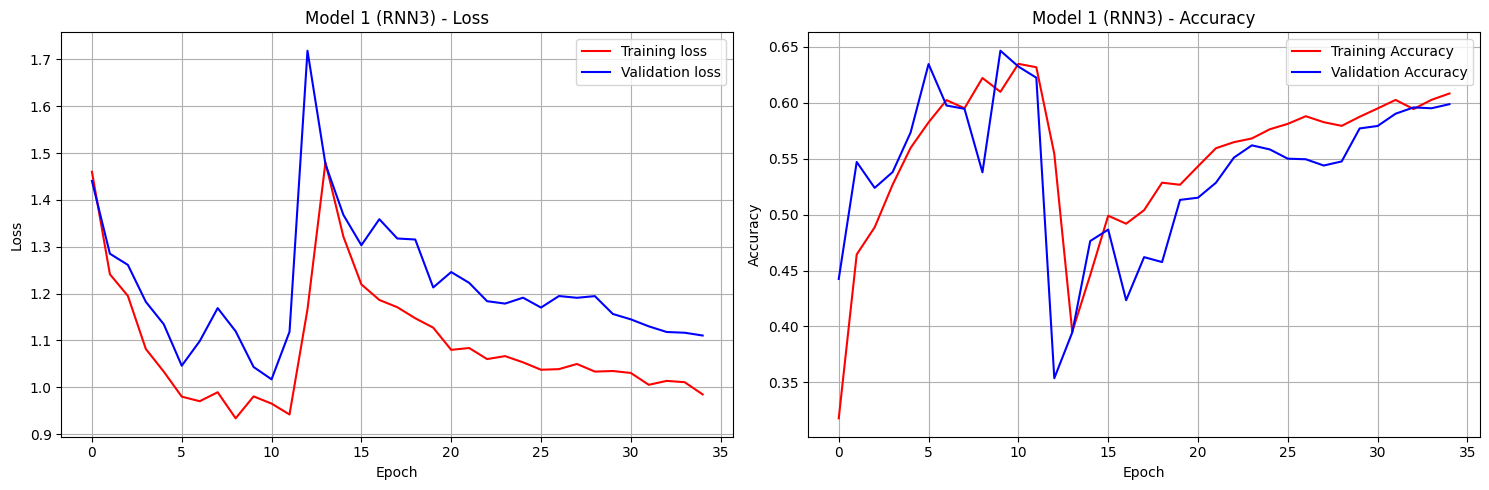

In [ ]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (RNN3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (RNN3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

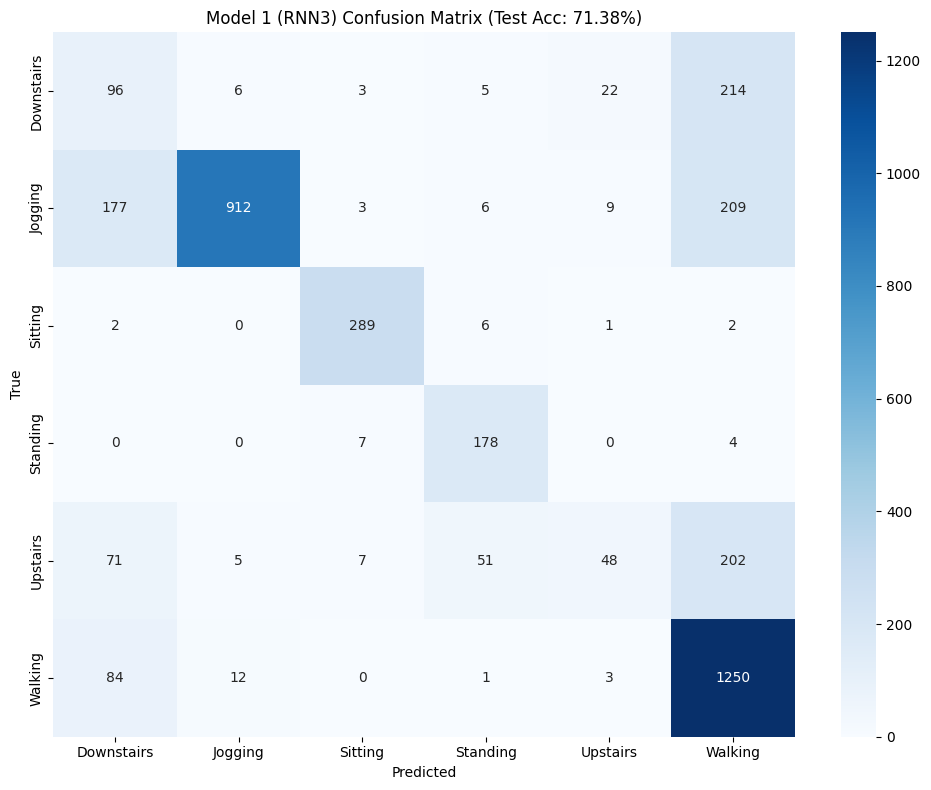

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (RNN3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()